In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import queer
from queer.arpes import arpes_mesh, arpes_path, binding_k
from queer.functions import get_rotation_matrix
from queer.mesh import angstrom2reciprocal
from queer.paths import data_path, results_path
from queer.response import spectral_from_eig


In [2]:
# Input files
file_path = data_path("materials", "ag_primitive")
hr = "wannier90_hr.dat"
model = queer.model(path=file_path,ef=8.310342,poscar='POSCAR')
g_vec = model.g_vec

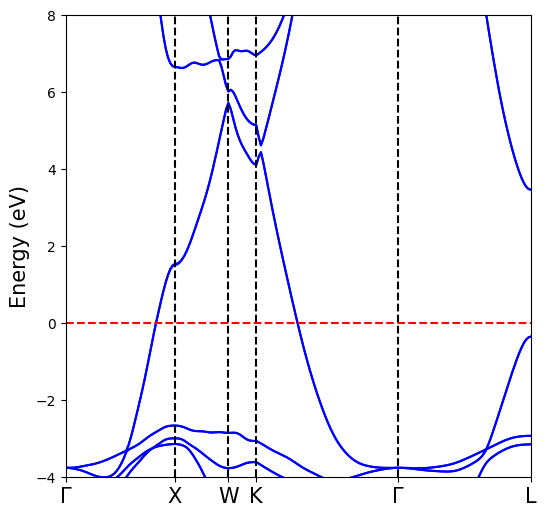

In [6]:
k_points = 200
band_path = model.kpath("GAMMA-X-W-K-GAMMA-L", k_points)
bands, ax = model.plot_band_path(band_path, ylim=(-4, 8))

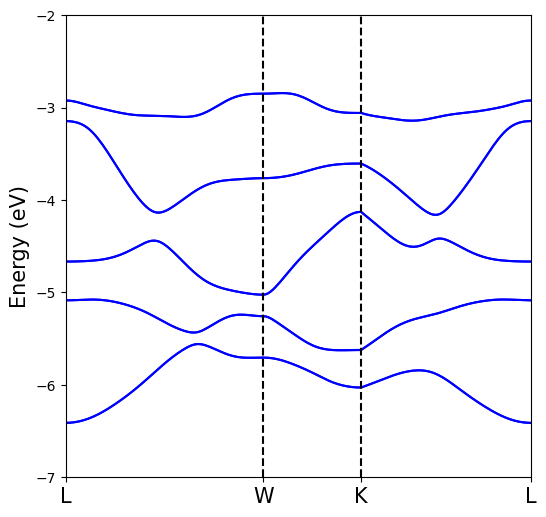

In [7]:
k_points = 200
band_path = model.kpath("L-W-K-L", k_points)
bands, ax = model.plot_band_path(band_path, ylim=(-7, -2))

In [8]:
N = 300
factor = 4
binding_range = [3.2, 6.2]
binding_step = 0.5
photon_energy = 21.2
fermi_energy = 0
V0 = 15
binding_energy=0

In [9]:
mesh_array =  np.array(arpes_mesh(photon_energy,fermi_energy,binding_energy,V0,N,factor,align=[[0,0,1],[1,1,1]]))

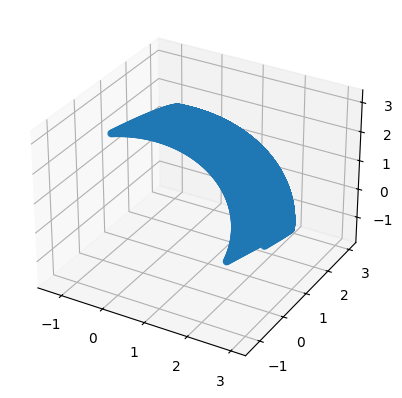

In [10]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(mesh_array.T[0],mesh_array.T[1],mesh_array.T[2])

plt.show()

In [11]:
inv_mesh_array = angstrom2reciprocal(mesh_array, g_vec)
    

In [12]:
band = model.calculate_energy(inv_mesh_array)

In [13]:
delta = 0.05  # eV
nband, nk = band.shape
near_any = np.any(np.abs(band) <= delta, axis=0)  # (nk,)
plt.scatter(kx[near_any], ky[near_any], s=6, alpha=0.9,c='red')

NameError: name 'kx' is not defined

In [16]:
# Function to format time in a readable way
def format_time(seconds):
    if seconds < 60:
        return f"{seconds:.2f} seconds"
    elif seconds < 3600:
        minutes = seconds / 60
        return f"{minutes:.2f} minutes"
    else:
        hours = seconds / 3600
        return f"{hours:.2f} hours"

In [ ]:
N = 100
factor = 6
binding_range = [4.7,6.7]
binding_step = 0.5
photon_energy = 21.2
fermi_energy = 0
V0 = [10,11,12]
align = [[0,0,1],[1,1,1]]
rot_mat = get_rotation_matrix([0,0,1],[1,1,1])
energy_shift=[0.15,0.2,0.25]
for shift in energy_shift:
    for v in V0:
        kmesh_dict = binding_k(photon_energy, fermi_energy, binding_range, binding_step, v, N, factor,align)

        start_total = time.time()
        # Energy calculations
        start_energy = time.time()
        energy_dict = {}
        for i, j in kmesh_dict.items():
            kmesh = np.array(j)
            inv_kmesh = angstrom2reciprocal(kmesh.T, g_vec)
            band = model.calculate_energy(inv_kmesh) 
            energy_dict[i] = band + shift
        end_energy = time.time()
        print(f"Energy calculations took {format_time(end_energy - start_energy)}")

        # Data processing: mesh tiling to intensity calculation
        start_data = time.time()
        mesh_tile_dict = {}
        band_tile_dict = {}
        for i, j in kmesh_dict.items():
            kmesh = np.array(j)
            tile_mesh = []
            for k in range(energy_dict[i].shape[0]):
                tile_mesh.append(kmesh.T)
            mesh_tile = np.array(tile_mesh).reshape(-1, 3)
            mesh_tile_dict[i] = mesh_tile
            band_tile = energy_dict[i].flatten()
            band_tile_dict[i] = band_tile

        df_dict = {}
        for i, j in kmesh_dict.items():
            mesh_tile = mesh_tile_dict[i]
            band_tile = band_tile_dict[i]
            df = pd.DataFrame()
            df['kx'] = mesh_tile.T[0]
            df['ky'] = mesh_tile.T[1]
            df['kz'] = mesh_tile.T[2]
            df['e'] = band_tile
            df_dict[i] = df

        df_shift = {name: df.copy(deep=True) for name, df in df_dict.items()}
        # energy_shift = df_shift[0].query('e<=0').max().e

        # for i, j in df_shift.items():
        #     j.e -= energy_shift

        intensity_dict = {}
        for i, j in df_shift.items():
            j["I"] = np.exp(-((j.e + i)**2) / (2 * 0.1**2))
            group_max = j.loc[j.groupby(['kx', 'ky'])['I'].idxmax()]
            intensity_dict[i] = group_max
        end_data = time.time()
        print(f"Data processing took {format_time(end_data - start_data)}")
        start_plot = time.time()
        for i, j in intensity_dict.items():
            K = np.array([j.kx,j.ky,j.kz])
            inv_trans = rot_mat.T@K
            fig = plt.figure(figsize=(5, 5))
            plt.scatter(inv_trans[0], inv_trans[1], c=j.I, cmap='inferno', s=1)
            # plt.scatter(j.kx, j.ky, c=j.I, cmap='inferno', s=1)
            plt.xlabel(r"$k_{x}$ [$\AA^{-1}$]")
            plt.ylabel(r"$k_{y}$ [$\AA^{-1}$]")
            plt.title(fr"${{E_B}}$={np.around(i,2)} eV  V_0: {v}, shift: {shift}")
            # plt.title(fr"${{V_0}}$={v} eV")
            plt.gca().set_facecolor('black')
            # plt.xlim(-2, 2)
            # plt.ylim(-2, 2)
            plt.tight_layout()
            output_dir = results_path("ag_primitive", "figs", f"V0_{v}_shift_{shift}")
            output_dir.mkdir(parents=True, exist_ok=True)
            figure_path = output_dir / f"{np.around(i,2)}.png"
            plt.savefig(figure_path, dpi=300, bbox_inches='tight')
            # frame_files.append(figure_path)
            # plt.close(fig)  # Close figure to free memory instead of showing
        end_plot = time.time()
        print(f"Plotting took {format_time(end_plot - start_plot)}")

        # Total execution time
        end_total = time.time()
        print(f"Total execution time: {format_time(end_total - start_total)}")

In [24]:
N = 100
factor = 4
binding_range = [4.7, 6.7]
binding_step = 0.5
photon_energy = 21.2
fermi_energy = 0
V0 = [12]
align = [[0, 0, 1], [1, 1, 1]]
rot_mat = get_rotation_matrix([0, 0, 1], [1, 1, 1])
energy_shift = [0.25]
tol = 0.1  # eV window around the binding energy slice

for shift in energy_shift:
    for v in V0:
        kmesh_dict = binding_k(photon_energy, fermi_energy, binding_range,
                               binding_step, v, N, factor, align)

        start_total = time.time()

        # ---- Energies (shift baked in) ----
        start_energy = time.time()
        energy_dict = {}
        for i, j in kmesh_dict.items():
            kmesh = np.array(j)
            inv_kmesh = angstrom2reciprocal(kmesh.T, g_vec)
            band = model.calculate_energy(inv_kmesh)
            energy_dict[i] = band + shift
        print(f"Energy calculations took {format_time(time.time() - start_energy)}")

        # ---- Tile k-mesh per band, then select points at E_B = i ----
        start_data = time.time()
        band_dict = {}
        for i, j in kmesh_dict.items():
            kmesh = np.array(j)                      # same convention as before
            n_bands = energy_dict[i].shape[0]
            tile_mesh = [kmesh.T for _ in range(n_bands)]
            mesh_tile = np.array(tile_mesh).reshape(-1, 3)
            band_tile = energy_dict[i].flatten()

            df = pd.DataFrame({
                'kx': mesh_tile[:, 0],
                'ky': mesh_tile[:, 1],
                'kz': mesh_tile[:, 2],
                'e':  band_tile,
            })
            # keep only points whose (shifted) energy sits at this binding energy
            band_dict[i] = df[np.abs(df.e + i) < tol].copy()
        print(f"Data processing took {format_time(time.time() - start_data)}")

        # ---- Transparent scatter, no intensity colormap ----
        start_plot = time.time()
        for i, j in band_dict.items():
            if len(j) == 0:
                continue
            K = np.array([j.kx.values, j.ky.values, j.kz.values])
            inv_trans = rot_mat.T @ K

            fig = plt.figure(figsize=(5, 5))
            plt.scatter(inv_trans[0], inv_trans[1],
                        color='white', s=2, alpha=0.25,
                        edgecolors='none', rasterized=True)
            plt.xlabel(r"$k_{x}$ [$\AA^{-1}$]")
            plt.ylabel(r"$k_{y}$ [$\AA^{-1}$]")
            plt.title(fr"$E_B$={np.around(i,2)} eV  $V_0$={v}, shift={shift}")
            plt.gca().set_facecolor('black')
            plt.tight_layout()

            output_dir = results_path("ag_primitive", "figs", f"V0_{v}_shift_{shift}")
            output_dir.mkdir(parents=True, exist_ok=True)
            figure_path = output_dir / f"{np.around(i,2)}.png"
            plt.savefig(figure_path, dpi=300, bbox_inches='tight')
            plt.close(fig)
        print(f"Plotting took {format_time(time.time() - start_plot)}")

        print(f"Total execution time: {format_time(time.time() - start_total)}")

Energy calculations took 48.81 seconds
Data processing took 0.02 seconds
Plotting took 1.32 seconds
Total execution time: 50.15 seconds


In [25]:
N = 100
factor = 4
binding_range = [4.7, 6.7]
binding_step = 0.5
photon_energy = 21.2
fermi_energy = 0
V0 = [12]
align = [[0, 0, 1], [1, 1, 1]]
rot_mat = get_rotation_matrix([0, 0, 1], [1, 1, 1])
energy_shift = [0.25]
tol = 0.1  # eV window around the binding energy slice

for shift in energy_shift:
    for v in V0:
        kmesh_dict = binding_k(photon_energy, fermi_energy, binding_range,
                               binding_step, v, N, factor, align)

        start_total = time.time()

        # ---- Energies (shift baked in) ----
        start_energy = time.time()
        energy_dict = {}
        for i, j in kmesh_dict.items():
            kmesh = np.array(j)
            inv_kmesh = angstrom2reciprocal(kmesh.T, g_vec)
            band = model.calculate_energy(inv_kmesh)
            energy_dict[i] = band + shift
        print(f"Energy calculations took {format_time(time.time() - start_energy)}")

        # ---- Tile k-mesh per band, then select points at E_B = i ----
        start_data = time.time()
        band_dict = {}
        for i, j in kmesh_dict.items():
            kmesh = np.array(j)
            n_bands = energy_dict[i].shape[0]
            tile_mesh = [kmesh.T for _ in range(n_bands)]
            mesh_tile = np.array(tile_mesh).reshape(-1, 3)
            band_tile = energy_dict[i].flatten()

            df = pd.DataFrame({
                'kx': mesh_tile[:, 0],
                'ky': mesh_tile[:, 1],
                'kz': mesh_tile[:, 2],
                'e':  band_tile,
            })
            band_dict[i] = df[np.abs(df.e + i) < tol].copy()
        print(f"Data processing took {format_time(time.time() - start_data)}")

        # ---- Transparent scatter on transparent canvas ----
        start_plot = time.time()
        for i, j in band_dict.items():
            if len(j) == 0:
                continue
            K = np.array([j.kx.values, j.ky.values, j.kz.values])
            inv_trans = rot_mat.T @ K

            fig, ax = plt.subplots(figsize=(5, 5))
            ax.scatter(inv_trans[0], inv_trans[1],
                       color='black', s=2, alpha=0.25,
                       edgecolors='none', rasterized=True)
            ax.set_xlabel(r"$k_{x}$ [$\AA^{-1}$]")
            ax.set_ylabel(r"$k_{y}$ [$\AA^{-1}$]")
            ax.set_title(fr"$E_B$={np.around(i,2)} eV  $V_0$={v}, shift={shift}")

            # make both figure and axes patches transparent
            fig.patch.set_alpha(0.0)
            ax.patch.set_alpha(0.0)

            plt.tight_layout()

            output_dir = results_path("ag_primitive", "figs", f"V0_{v}_shift_{shift}")
            output_dir.mkdir(parents=True, exist_ok=True)
            figure_path = output_dir / f"{np.around(i,2)}.png"
            plt.savefig(figure_path, dpi=300, bbox_inches='tight', transparent=True)
            plt.close(fig)
        print(f"Plotting took {format_time(time.time() - start_plot)}")

        print(f"Total execution time: {format_time(time.time() - start_total)}")

Energy calculations took 45.29 seconds
Data processing took 0.02 seconds
Plotting took 1.49 seconds
Total execution time: 46.79 seconds


In [ ]:
kmesh.shape

In [ ]:
df_shift

In [ ]:
bands = model.calculate_energy(band_path)
deltaE=np.linspace(-3,0,100)

spectral_array = []
for i,eig in enumerate(bands.T):
    spectral_array.append(spectral_from_eig(eig,omega_list=deltaE,eta=0.1))
plt.pcolormesh(np.arange(len(band_path.path)),deltaE,np.array(spectral_array).T,cmap='magma')
for i in band_path.sym[1:-1]:
    plt.axvline(i, c="white", linestyle="--")
# plt.axhline(0, linestyle="--", color="red")
plt.xticks(ticks=band_path.sym, labels=band_path.labels, fontsize=15)
plt.xlim(band_path.sym[0], band_path.sym[-1])
plt.ylabel('$E - E_F$ (eV)')
plt.show()


In [ ]:
curved_path = arpes_path(band_path, g_vec,Ek=21.2,V0=15)
bands = model.calculate_energy(curved_path)

In [ ]:
deltaE=np.linspace(-3,0,100)

spectral_array = []
for i,eig in enumerate(bands.T):
    spectral_array.append(spectral_from_eig(eig,omega_list=deltaE,eta=0.1))


In [ ]:
plt.pcolormesh(np.arange(len(band_path.path)),deltaE,np.array(spectral_array).T,cmap='magma')
for i in band_path.sym[1:-1]:
    plt.axvline(i, c="white", linestyle="--")
# plt.axhline(0, linestyle="--", color="red")
plt.xticks(ticks=band_path.sym, labels=band_path.labels, fontsize=15)
plt.xlim(band_path.sym[0], band_path.sym[-1])
plt.ylabel('$E - E_F$ (eV)')
plt.show()

In [ ]:
v0_array = [15]
deltaE=np.linspace(0,-3,300)
v0_dict ={}
for v0 in v0_array:
    spectral_dict = {}
    for delta in deltaE:
        spectral_dict[delta] = []
        curved_path = arpes_path(band_path, g_vec,Ek=21.2-delta,V0=v0)
        bands = model.calculate_energy(curved_path)
        if delta==0:
            negatives = bands[bands < 0]
            max_neg = negatives.max()
        for i,eig in enumerate(bands.T):
            spectral_dict[delta].append(spectral_from_eig(eig-max_neg,omega_list=[delta],eta=0.1))
    v0_dict[v0] = spectral_dict


In [ ]:
for j,spectral_dict in v0_dict.items():
    y = np.array(sorted(spectral_dict.keys()))
    
    # Stack and flatten each (Nk,1) array into shape (Nk,)
    A = np.vstack([np.array(spectral_dict[val]).flatten() for val in y])
    
    # Define x-axis (use your actual k-values if available)
    x = np.arange(A.shape[1])
    plt.pcolormesh(x, y, A, shading='auto',cmap='magma')
    for i in band_path.sym[1:-1]:
        plt.axvline(i, c="white", linestyle="--")
    # plt.axhline(0, linestyle="--", color="red")
    plt.xticks(ticks=band_path.sym, labels=band_path.labels, fontsize=15)
    plt.xlim(band_path.sym[0], band_path.sym[-1])
    plt.ylabel('$E - E_F$ [eV]')
    plt.title(rf"$V_0 = {j}$ eV")
    plt.xlabel(r"High-symmetry Points [$\AA^{-1}$] ")
    plt.tight_layout()
    output_dir = results_path("v0_sweep", "figs", "arpes_path", "k_400")
    output_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_dir / f"V0_{j}.png",
            dpi=300,
            bbox_inches='tight')
    plt.show()
